# Within-language(En)

## Injection

### 1. 环境配置、路径设置与模型加载

In [8]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import sys
from transformers import AutoModel, AutoTokenizer

# 1. 路径设置
sys.path.append("/mnt/ssd/weicheng/data_interns/yahan/syntactic-parsing/src/")
from train_parser import BiaffineDependencyParser, mask_arc_scores

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# En模型 checkpoint
checkpoint_path = "/mnt/ssd/weicheng/data_interns/yahan/syntactic-parsing/models/last4_en/best_model.pt"

# 2. 加载 Checkpoint
print(f"正在从 {checkpoint_path} 加载模型...")
checkpoint = torch.load(checkpoint_path, map_location=device)
args = checkpoint["args"]

# 3. 初始化 Encoder 和 Parser
tokenizer = AutoTokenizer.from_pretrained(args["model_name"])
encoder = AutoModel.from_pretrained(args["model_name"])

# 自动获取 Label 数量
num_labels = checkpoint["model_state_dict"]["rel_biaffine.weight"].shape[0]

model = BiaffineDependencyParser(
    encoder=encoder,
    num_labels=num_labels,
    hidden_size=encoder.config.hidden_size,
    mlp_size=args["mlp_size"],
    dropout=args["dropout"],
)

# 加载权重并设置为评估模式
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device).eval()

print(f"模型加载成功！运行设备: {device}")

正在从 /mnt/ssd/weicheng/data_interns/yahan/syntactic-parsing/models/last4_en/best_model.pt 加载模型...
模型加载成功！运行设备: cuda


### 2. 数据加载与 Token 索引映射工具

In [9]:
import json

# ===================================================
# 工具函数：标点分离的 tokenization（与数据标注对齐）
# ===================================================
def split_with_punct(text):
    tokens = []
    for word in text.split():
        if word[-1] in '.,:;?!' and len(word) > 1:
            tokens.append(word[:-1])
            tokens.append(word[-1])
        else:
            tokens.append(word)
    return tokens

def build_indices_from_verify(dataset):
    """根据 en_verify/de_verify 自动计算 0-based index"""
    errors = []
    for item in dataset:
        for lang in ['en', 'de']:
            verify = item.get(f'{lang}_verify', {})
            if not verify:
                continue
            clean_text = item[f'{lang}_clean']
            tokens = split_with_punct(clean_text)
            indices = {}
            for role, word in verify.items():
                matches = [i for i, t in enumerate(tokens) if t.lower() == word.lower()]
                if not matches:
                    errors.append(f"id={item['id']} {lang} {role}='{word}' not found in {tokens}")
                else:
                    indices[role] = matches[0]
            item[f'{lang}_indices'] = indices
    return errors

def get_token_indices(tokenizer, text, word_idx):
    """
    返回 word_idx（split_with_punct 的 0-based index）对应的 first-subword token index。
    """
    words = split_with_punct(text)
    encoding = tokenizer(
        words,
        is_split_into_words=True,
        add_special_tokens=True
    )
    word_ids = encoding.word_ids()

    for i, wid in enumerate(word_ids):
        if wid == word_idx:
            if i == 0 or word_ids[i-1] != word_idx:
                return [i]
    return []

# def apply_first_subword_mask(arc_scores, tokenizer, text, device):
#     words = split_with_punct(text)
#     encoding = tokenizer(words, is_split_into_words=True, add_special_tokens=True)
#     word_ids = encoding.word_ids()
#     first_subword_mask = torch.tensor([[
#         1 if (word_ids[i] is not None and (i == 0 or word_ids[i] != word_ids[i-1])) else 0
#         for i in range(len(word_ids))
#     ]]).to(device)
#     return mask_arc_scores(arc_scores, first_subword_mask)

# ===================================================
# 加载数据
# ===================================================
dataset = []
data_path = '../data/en_de_nsubj_data.jsonl'

try:
    with open(data_path, 'r', encoding='utf-8') as f:
        for line in f:
            dataset.append(json.loads(line))
    print(f"✅ 成功加载数据，共 {len(dataset)} 条 Minimal Pairs 测试样本。")
except FileNotFoundError:
    print(f"❌ 错误：未找到 {data_path}")

# ===================================================
# 自动从 verify 字段生成 index，并校验
# ===================================================
errors = build_indices_from_verify(dataset)
if errors:
    print("❌ 以下条目需要人工复查：")
    for e in errors:
        print(" ", e)
else:
    print(f"✅ 全部 {len(dataset)} 条数据 index 自动生成成功")

# ===================================================
# 快速抽样校验
# ===================================================
if dataset:
    sample = dataset[0]
    for lang in ['en']:
        text = sample[f'{lang}_clean']
        tokens = split_with_punct(text)
        print(f"\n--- {lang} 索引校验 ---")
        print(f"tokens: {tokens}")
        for role, idx in sample[f'{lang}_indices'].items():
            print(f"  {role}={idx} -> '{tokens[idx]}'")

✅ 成功加载数据，共 50 条 Minimal Pairs 测试样本。
✅ 全部 50 条数据 index 自动生成成功

--- en 索引校验 ---
tokens: ['The', 'girl', 'with', 'the', 'red', 'roses', 'smiles', '.']
  subj=1 -> 'girl'
  verb=6 -> 'smiles'
  attr=5 -> 'roses'


### 3. 评估指标 (UAS/Logit) 与 激活值获取 Hook

In [10]:
# ===================================================
# 块 3-B: 核心指标与激活获取函数 (最小修改版)
# ===================================================

def get_nsubj_target_tokens(item, tokenizer, text, lang='en'):
    key = f'{lang}_indices'
    s_idx = item[key]['subj']
    v_idx = item[key]['verb']
    
    s_list = get_token_indices(tokenizer, text, s_idx)
    v_list = get_token_indices(tokenizer, text, v_idx)
    
    if not s_list or not v_list:
        return None, None
        
    return s_list[0], v_list[0]


def nsubj_uas_metric(arc_scores, item, tokenizer, text, lang='en'):
    subj_token, _ = get_nsubj_target_tokens(item, tokenizer, text, lang)
    if subj_token is None: return 0.0
    
    pred_head_token = arc_scores[0, subj_token].argmax(dim=-1).item()
    verb_range = get_token_indices(tokenizer, text, item[f'{lang}_indices']['verb'])
    return 1.0 if pred_head_token in verb_range else 0.0

def nsubj_logit_metric(arc_scores, item, tokenizer, text, lang='en'):
    subj_token, verb_token = get_nsubj_target_tokens(item, tokenizer, text, lang)
    if subj_token is None: return -999.0
    
    logit = arc_scores[0, subj_token, verb_token]
    return logit.item()

def get_activations(model, inputs):
    activations = {}
    
    def save_hook(name):
        def hook(mod, inp, out):
            val = out[0] if isinstance(out, tuple) else out
            activations[name] = val.detach()
        return hook
    
    layers = model.encoder.encoder.layer
    handles = [layer.attention.self.register_forward_hook(save_hook(f"layer_{i}")) 
               for i, layer in enumerate(layers)]
    
    with torch.no_grad():
        _ = model(**inputs)
        
    for h in handles: h.remove()
    return activations

# ===================================================
# ★ 新增：apply_first_subword_mask 辅助函数
# 训练时始终使用 mask_arc_scores，推理时也必须一致，
# 否则 subword token 会被当作合法 head 候选，导致 UAS/logit 异常。
# ===================================================
def apply_first_subword_mask(arc_scores, tokenizer, text, device):
    words = text.split()
    encoding = tokenizer(words, is_split_into_words=True, add_special_tokens=True)
    word_ids = encoding.word_ids()
    first_subword_mask = torch.tensor([[
        1 if (word_ids[i] is not None and (i == 0 or word_ids[i] != word_ids[i-1])) else 0
        for i in range(len(word_ids))
    ]]).to(device)
    return mask_arc_scores(arc_scores, first_subword_mask)

### 4. 单 Head Activation Patching 实验

In [11]:
# ===================================================
# 块 4-A: 计算 Corrupted Baseline (输入矛盾句子)
# ===================================================

corrupted_uas_list = []
corrupted_logit_list = []

for item in dataset:
    corr_text = item['en_corr']
    corr_inputs = tokenizer(corr_text, return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = model(**corr_inputs)
        arc_scores = outputs[0] if isinstance(outputs, (tuple, list)) else outputs.arc_scores
    
    # ★ 修复：推理时补上 first_subword_mask，与训练保持一致
    arc_scores = apply_first_subword_mask(arc_scores, tokenizer, corr_text, device)
    
    uas = nsubj_uas_metric(arc_scores, item, tokenizer, corr_text, lang='en')
    logit = nsubj_logit_metric(arc_scores, item, tokenizer, corr_text, lang='en')
    
    corrupted_uas_list.append(uas)
    corrupted_logit_list.append(logit)

print(f"--- Corrupted Baseline (矛盾状态) ---")
print(f"Mean UAS: {np.mean(corrupted_uas_list):.4f}")
print(f"Mean Logit: {np.mean(corrupted_logit_list):.4f}")

if np.mean(corrupted_uas_list) > 0.7:
    print("💡 提示：模型在矛盾句下的 UAS 依然很高。我们将主要观察注入激活后 Logit 的进一步提升。")


# ===================================================
# 额外测试: 计算 Clean Baseline (正常句子的表现)
# ===================================================

clean_uas_list = []
clean_logit_list = []

print("🧪 正在评估 Clean 状态下的模型表现...")

for item in dataset:
    clean_text = item['en_clean']
    # ★ 修复：用 clean_inputs 而不是上一个循环遗留的 corr_inputs
    clean_inputs = tokenizer(clean_text, return_tensors="pt").to(device)
    
    with torch.no_grad():
        # ★ 修复：model 输入改为 clean_inputs
        outputs = model(**clean_inputs)
        arc_scores = outputs[0] if isinstance(outputs, (tuple, list)) else outputs.arc_scores
    
    # ★ 修复：mask 基于 clean_text，不是 corr_text
    arc_scores = apply_first_subword_mask(arc_scores, tokenizer, clean_text, device)
    
    uas = nsubj_uas_metric(arc_scores, item, tokenizer, clean_text, lang='en')
    logit = nsubj_logit_metric(arc_scores, item, tokenizer, clean_text, lang='en')
    
    clean_uas_list.append(uas)
    clean_logit_list.append(logit)

print(f"\n✅ --- Clean Baseline (正常状态) ---")
print(f"Mean UAS: {np.mean(clean_uas_list):.4f}")
print(f"Mean Logit: {np.mean(clean_logit_list):.4f}")

--- Corrupted Baseline (矛盾状态) ---
Mean UAS: 0.6800
Mean Logit: -6.0399
🧪 正在评估 Clean 状态下的模型表现...

✅ --- Clean Baseline (正常状态) ---
Mean UAS: 0.8200
Mean Logit: -4.6024


In [20]:
# ===================================================
# 块 4-B: 统一 Patching 实验
# ===================================================

n_layers = model.encoder.config.num_hidden_layers
n_heads = model.encoder.config.num_attention_heads

uas_heatmap = np.zeros((n_layers, n_heads))
logit_heatmap = np.zeros((n_layers, n_heads))

# --- 第一阶段：预计算与缓存 ---
print("📦 正在预计算 Clean 激活值与 Corrupted Baseline...")
all_clean_acts = []
all_base_logits = []
all_corr_inputs = []

for item in dataset:
    c_text = item['en_clean']
    c_in = tokenizer(c_text, return_tensors="pt").to(device)
    all_clean_acts.append(get_activations(model, c_in))
    
    r_text = item['en_corr']
    r_in = tokenizer(r_text, return_tensors="pt").to(device)
    all_corr_inputs.append(r_in)
    
    with torch.no_grad():
        out = model(input_ids=r_in['input_ids'], attention_mask=r_in['attention_mask'])
        arc = out[0] if isinstance(out, (tuple, list)) else out.arc_scores
    arc = apply_first_subword_mask(arc, tokenizer, r_text, device)
    all_base_logits.append(nsubj_logit_metric(arc, item, tokenizer, r_text))

# --- 第二阶段：双指标循环干预 ---
print(f"🚀 开始逐层扫描 ({n_layers}x{n_heads} Heads)...")

for l in range(n_layers):
    for h in range(n_heads):
        total_uas = 0
        total_logit_diff = 0
        
        for i, item in enumerate(dataset):
            clean_acts = all_clean_acts[i]
            corr_inputs = all_corr_inputs[i]
            base_logit = all_base_logits[i]
            corr_text = item['en_corr']

            def patch_hook(module, input, output, current_l=l, current_h=h, c_acts=clean_acts):
                hidden_states = output[0] if isinstance(output, tuple) else output
                batch, corr_seq, dim = hidden_states.shape
                head_dim = dim // n_heads
                
                clean_hidden = c_acts[f"layer_{current_l}"]
                batch_c, clean_seq, _ = clean_hidden.shape
                
                out_heads = hidden_states.reshape(batch, corr_seq, n_heads, head_dim).clone()
                clean_heads = clean_hidden.reshape(batch_c, clean_seq, n_heads, head_dim)
                
                min_seq = min(corr_seq, clean_seq)
                out_heads[:, :min_seq, current_h, :] = clean_heads[:, :min_seq, current_h, :]
                
                new_out = out_heads.reshape(batch, corr_seq, dim)
                return (new_out,) + output[1:] if isinstance(output, tuple) else new_out

            handle = model.encoder.encoder.layer[l].attention.self.register_forward_hook(patch_hook)
            with torch.no_grad():
                patched_out = model(input_ids=corr_inputs['input_ids'], attention_mask=corr_inputs['attention_mask'])
                patched_arc = patched_out[0] if isinstance(patched_out, (tuple, list)) else patched_out.arc_scores
            handle.remove()
            
            patched_arc = apply_first_subword_mask(patched_arc, tokenizer, corr_text, device)
            
            total_uas += nsubj_uas_metric(patched_arc, item, tokenizer, corr_text)
            patched_logit = nsubj_logit_metric(patched_arc, item, tokenizer, corr_text)
            total_logit_diff += (patched_logit - base_logit)
            
        uas_heatmap[l, h] = total_uas / len(dataset)
        logit_heatmap[l, h] = total_logit_diff / len(dataset)
        
    print(f"Layer {l:2d} 完成 | Max UAS: {np.max(uas_heatmap[l]):.2f} | Max Logit Boost: {np.max(logit_heatmap[l]):.4f}")

print("\n✅ 实验顺利完成！") 
print(f"Clean UAS: {np.mean(clean_uas_list):.4f}, Logit: {np.mean(clean_logit_list):.4f}") 
print(f"Corr UAS: {np.mean(corrupted_uas_list):.4f}, Logit: {np.mean(corrupted_logit_list):.4f}") 
print(f"差距 ΔUAS: {np.mean(clean_uas_list)-np.mean(corrupted_uas_list):.4f}, ΔLogit: {np.mean(clean_logit_list)-np.mean(corrupted_logit_list):.4f}")

📦 正在预计算 Clean 激活值与 Corrupted Baseline...
🚀 开始逐层扫描 (12x12 Heads)...
Layer  0 完成 | Max UAS: 0.68 | Max Logit Boost: 0.1973
Layer  1 完成 | Max UAS: 0.68 | Max Logit Boost: 0.2356
Layer  2 完成 | Max UAS: 0.68 | Max Logit Boost: 0.2453
Layer  3 完成 | Max UAS: 0.68 | Max Logit Boost: 0.2062
Layer  4 完成 | Max UAS: 0.68 | Max Logit Boost: 0.3074
Layer  5 完成 | Max UAS: 0.68 | Max Logit Boost: 0.2514
Layer  6 完成 | Max UAS: 0.70 | Max Logit Boost: 0.4394
Layer  7 完成 | Max UAS: 0.72 | Max Logit Boost: 0.2635
Layer  8 完成 | Max UAS: 0.70 | Max Logit Boost: 0.7249
Layer  9 完成 | Max UAS: 0.68 | Max Logit Boost: 0.2427
Layer 10 完成 | Max UAS: 0.68 | Max Logit Boost: 0.1918
Layer 11 完成 | Max UAS: 0.68 | Max Logit Boost: 0.0001

✅ 实验顺利完成！
Clean UAS: 0.8200, Logit: -4.6024
Corr UAS: 0.6800, Logit: -6.0399
差距 ΔUAS: 0.1400, ΔLogit: 1.4376


### 5. 热力图绘制与关键 Head 识别

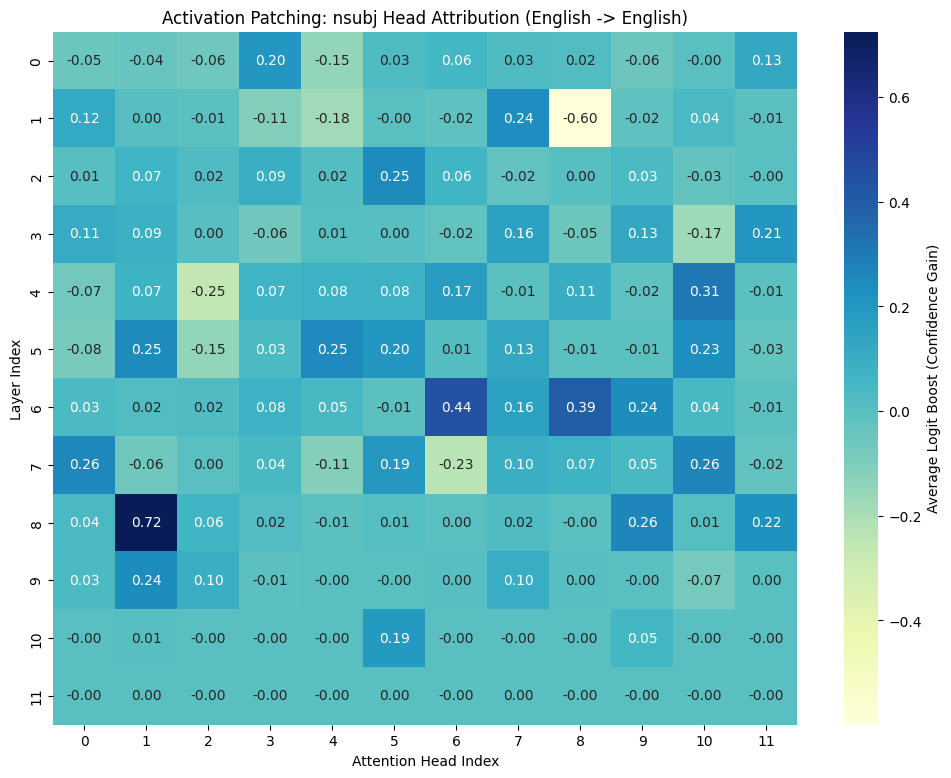

对 nsubj 信心提升最大的前 5 个关键 Head (Core Circuit Candidates):
------------------------------------------------------------
Rank 1: Layer  8, Head  1 | Avg Logit Boost: +0.7249
Rank 2: Layer  6, Head  6 | Avg Logit Boost: +0.4394
Rank 3: Layer  6, Head  8 | Avg Logit Boost: +0.3899
Rank 4: Layer  4, Head 10 | Avg Logit Boost: +0.3074
Rank 5: Layer  7, Head 10 | Avg Logit Boost: +0.2635
------------------------------------------------------------


In [21]:
plt.figure(figsize=(12, 9))

sns.heatmap(logit_heatmap, annot=True, fmt=".2f", cmap="YlGnBu", 
            cbar_kws={'label': 'Average Logit Boost (Confidence Gain)'})

plt.title("Activation Patching: nsubj Head Attribution (English -> English)")
plt.xlabel("Attention Head Index")
plt.ylabel("Layer Index")
plt.show()

# 找出表现最好的前 5 个 Head
flat_idx = np.argsort(logit_heatmap.flatten())[::-1]

print("对 nsubj 信心提升最大的前 5 个关键 Head (Core Circuit Candidates):")
print("-" * 60)
for i in range(5):
    idx = flat_idx[i]
    layer_num = idx // n_heads
    head_num = idx % n_heads
    boost_val = logit_heatmap.flatten()[idx]
    print(f"Rank {i+1}: Layer {layer_num:2d}, Head {head_num:2d} | Avg Logit Boost: {boost_val:+.4f}")
print("-" * 60)

### 6. 组合回路实验 (Testing the Joint Circuit)

In [22]:
# ===================================================
# 块 5: 组合电路扫描
# ===================================================
import itertools

for module in model.modules(): module._forward_hooks.clear()

candidate_k = 6 
flat_indices = np.argsort(logit_heatmap.flatten())[::-1]
candidate_heads = [(int(i // n_heads), int(i % n_heads)) for i in flat_indices[:candidate_k]]

print(f"🎯 候选池: {candidate_heads}")
combination_results = []

for r in range(1, candidate_k + 1):
    sub_circuits = list(itertools.combinations(candidate_heads, r))
    print(f"正在评估规模为 {r} 的组合 ({len(sub_circuits)} 种)...")
    
    for circuit in sub_circuits:
        total_logit_diff = 0
        
        current_layer2heads = {}
        for l, h in circuit:
            current_layer2heads.setdefault(l, []).append(h)

        for i, item in enumerate(dataset):
            clean_acts = all_clean_acts[i]
            corr_inputs = all_corr_inputs[i]
            base_logit = all_base_logits[i]
            r_text = item['en_corr']

            def make_patch_hook(l_idx, h_list, cached_acts=clean_acts):
                def hook(module, input, output):
                    hidden = output[0] if isinstance(output, tuple) else output
                    batch, r_seq, dim = hidden.shape
                    
                    clean_hidden = cached_acts[f"layer_{l_idx}"]
                    _, c_seq, _ = clean_hidden.shape
                    
                    out_heads = hidden.reshape(batch, r_seq, n_heads, dim // n_heads).clone()
                    clean_heads = clean_hidden.reshape(batch, c_seq, n_heads, dim // n_heads)
                    
                    min_seq = min(r_seq, c_seq)
                    for h_idx in h_list:
                        out_heads[:, :min_seq, h_idx, :] = clean_heads[:, :min_seq, h_idx, :]
                    
                    new_out = out_heads.reshape(batch, r_seq, dim)
                    return (new_out,) + output[1:] if isinstance(output, tuple) else new_out
                return hook

            handles = []
            for l_idx, h_list in current_layer2heads.items():
                h = model.encoder.encoder.layer[l_idx].attention.self.register_forward_hook(
                    make_patch_hook(l_idx, h_list)
                )
                handles.append(h)

            try:
                with torch.no_grad():
                    outputs = model(input_ids=corr_inputs['input_ids'], attention_mask=corr_inputs['attention_mask'])
                    arc_scores = outputs[0] if isinstance(outputs, (tuple, list)) else outputs.arc_scores
                arc_scores = apply_first_subword_mask(arc_scores, tokenizer, r_text, device)
                patched_logit = nsubj_logit_metric(arc_scores, item, tokenizer, r_text)
                total_logit_diff += (patched_logit - base_logit)
            finally:
                for h in handles: h.remove()

        combination_results.append({
            "circuit": circuit,
            "size": r,
            "avg_logit_boost": total_logit_diff / len(dataset)
        })

combination_results.sort(key=lambda x: x['avg_logit_boost'], reverse=True)
print("\n" + "="*60)
print(f"🏆 最佳电路发现 (Top 10 Sub-Circuits)")
for i, res in enumerate(combination_results[:10]):
    print(f"Rank {i+1} [Size {res['size']}]: {res['circuit']} | Boost: {res['avg_logit_boost']:+.4f}")

🎯 候选池: [(8, 1), (6, 6), (6, 8), (4, 10), (7, 10), (8, 9)]
正在评估规模为 1 的组合 (6 种)...
正在评估规模为 2 的组合 (15 种)...
正在评估规模为 3 的组合 (20 种)...
正在评估规模为 4 的组合 (15 种)...
正在评估规模为 5 的组合 (6 种)...
正在评估规模为 6 的组合 (1 种)...

🏆 最佳电路发现 (Top 10 Sub-Circuits)
Rank 1 [Size 6]: ((8, 1), (6, 6), (6, 8), (4, 10), (7, 10), (8, 9)) | Boost: +1.3924
Rank 2 [Size 5]: ((8, 1), (6, 6), (6, 8), (7, 10), (8, 9)) | Boost: +1.3613
Rank 3 [Size 5]: ((8, 1), (6, 6), (6, 8), (4, 10), (8, 9)) | Boost: +1.3369
Rank 4 [Size 5]: ((8, 1), (6, 8), (4, 10), (7, 10), (8, 9)) | Boost: +1.3249
Rank 5 [Size 4]: ((8, 1), (6, 6), (6, 8), (8, 9)) | Boost: +1.2859
Rank 6 [Size 5]: ((8, 1), (6, 6), (4, 10), (7, 10), (8, 9)) | Boost: +1.2682
Rank 7 [Size 4]: ((8, 1), (6, 8), (7, 10), (8, 9)) | Boost: +1.2508
Rank 8 [Size 4]: ((8, 1), (6, 6), (7, 10), (8, 9)) | Boost: +1.2335
Rank 9 [Size 4]: ((8, 1), (6, 8), (4, 10), (8, 9)) | Boost: +1.2325
Rank 10 [Size 5]: ((8, 1), (6, 6), (6, 8), (4, 10), (7, 10)) | Boost: +1.2120


## Ablation

### 7. 全量消融热力图 (Ablation Sensitivity Analysis)

📦 正在预计算 Clean 基准分值...
🚀 开始逐个消融扫描 (12x12 Heads)...
Layer  0 完成 | 最大 Logit 跌幅: 0.3243
Layer  1 完成 | 最大 Logit 跌幅: 0.3441
Layer  2 完成 | 最大 Logit 跌幅: 0.3117
Layer  3 完成 | 最大 Logit 跌幅: 0.3581
Layer  4 完成 | 最大 Logit 跌幅: 0.8908
Layer  5 完成 | 最大 Logit 跌幅: 0.7595
Layer  6 完成 | 最大 Logit 跌幅: 0.8807
Layer  7 完成 | 最大 Logit 跌幅: 0.6594
Layer  8 完成 | 最大 Logit 跌幅: 0.6580
Layer  9 完成 | 最大 Logit 跌幅: 0.3525
Layer 10 完成 | 最大 Logit 跌幅: 0.4590
Layer 11 完成 | 最大 Logit 跌幅: 0.0225


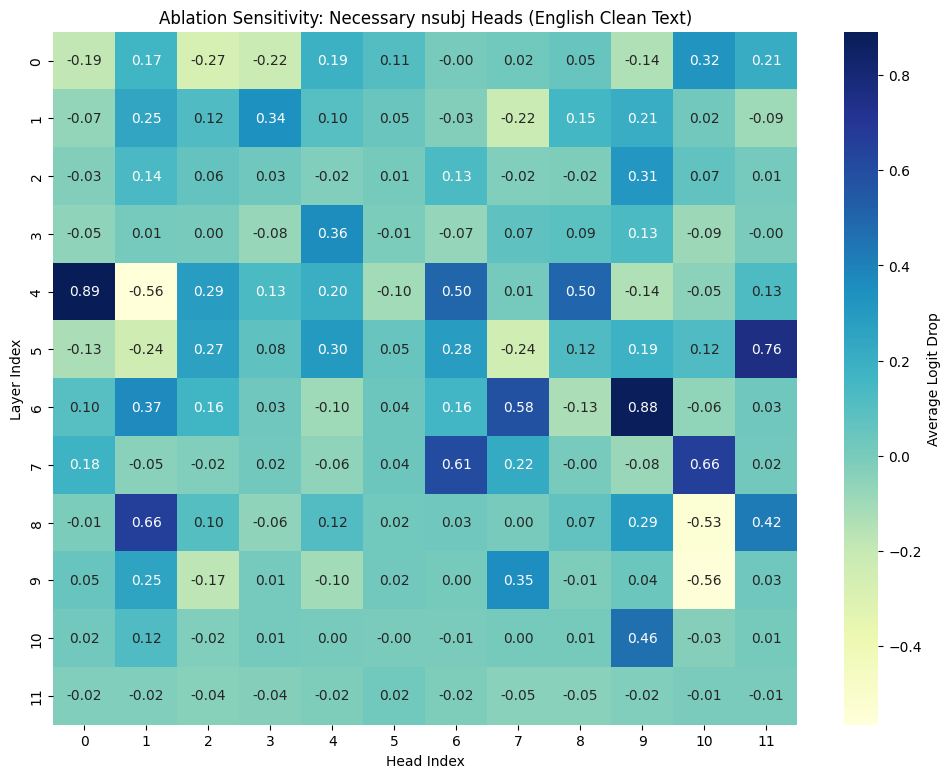

消融后导致信心跌幅最大的前 5 个 Head (Most Essential Heads):
------------------------------------------------------------
Rank 1: Layer  4, Head  0 | Avg Logit Drop: 0.8908
Rank 2: Layer  6, Head  9 | Avg Logit Drop: 0.8807
Rank 3: Layer  5, Head 11 | Avg Logit Drop: 0.7595
Rank 4: Layer  7, Head 10 | Avg Logit Drop: 0.6594
Rank 5: Layer  8, Head  1 | Avg Logit Drop: 0.6580
------------------------------------------------------------


In [17]:
# ===================================================
# 块 6: 消融实验 (Ablation Study)
# ===================================================

for module in model.modules(): module._forward_hooks.clear()

n_layers = model.encoder.config.num_hidden_layers
n_heads = model.encoder.config.num_attention_heads
ablation_heatmap = np.zeros((n_layers, n_heads))

# --- 第一阶段：计算 Clean 基准 ---
print("📦 正在预计算 Clean 基准分值...")
all_clean_logits = []
for item in dataset:
    text = item['en_clean']
    inputs = tokenizer(text, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model(**inputs)
        arc = out[0] if isinstance(out, (tuple, list)) else out.arc_scores
    # ★ 修复：补 mask
    arc = apply_first_subword_mask(arc, tokenizer, text, device)
    all_clean_logits.append(nsubj_logit_metric(arc, item, tokenizer, text))

# --- 第二阶段：逐个消融扫描 ---
print(f"🚀 开始逐个消融扫描 ({n_layers}x{n_heads} Heads)...")

for l in range(n_layers):
    for h in range(n_heads):
        total_logit_drop = 0
        
        for i, item in enumerate(dataset):
            text = item['en_clean']
            inputs = tokenizer(text, return_tensors="pt").to(device)
            clean_logit = all_clean_logits[i]
            
            def ablation_hook(module, input, output, current_h=h):
                hidden = output[0] if isinstance(output, tuple) else output
                batch, seq, dim = hidden.shape
                head_dim = dim // n_heads
                out_heads = hidden.reshape(batch, seq, n_heads, head_dim).clone()
                out_heads[:, :, current_h, :] = 0.0 
                new_out = out_heads.reshape(batch, seq, dim)
                return (new_out,) + output[1:] if isinstance(output, tuple) else new_out

            handle = model.encoder.encoder.layer[l].attention.self.register_forward_hook(ablation_hook)
            try:
                with torch.no_grad():
                    ablated_out = model(**inputs)
                    ablated_arc = ablated_out[0] if isinstance(ablated_out, (tuple, list)) else ablated_out.arc_scores
                # ★ 修复：补 mask
                ablated_arc = apply_first_subword_mask(ablated_arc, tokenizer, text, device)
                ablated_logit = nsubj_logit_metric(ablated_arc, item, tokenizer, text)
                total_logit_drop += (clean_logit - ablated_logit)
            finally:
                handle.remove()
            
        ablation_heatmap[l, h] = total_logit_drop / len(dataset)
        
    print(f"Layer {l:2d} 完成 | 最大 Logit 跌幅: {np.max(ablation_heatmap[l]):.4f}")

plt.figure(figsize=(12, 9))
sns.heatmap(ablation_heatmap, annot=True, fmt=".2f", cmap="YlGnBu", 
            cbar_kws={'label': 'Average Logit Drop'})
plt.title("Ablation Sensitivity: Necessary nsubj Heads (English Clean Text)")
plt.xlabel("Head Index")
plt.ylabel("Layer Index")
plt.show()

flat_idx = np.argsort(ablation_heatmap.flatten())[::-1]
print("消融后导致信心跌幅最大的前 5 个 Head (Most Essential Heads):")
print("-" * 60)
for i in range(5):
    idx = flat_idx[i]
    l_num = idx // n_heads
    h_num = idx % n_heads
    drop_val = ablation_heatmap.flatten()[idx]
    print(f"Rank {i+1}: Layer {l_num:2d}, Head {h_num:2d} | Avg Logit Drop: {drop_val:.4f}")
print("-" * 60)

### 8. 组合消融搜索 (Ablation-based Sub-Circuit Search)

In [23]:
# ===================================================
# 块 7: 组合消融测试
# ===================================================
import itertools

for module in model.modules(): module._forward_hooks.clear()

candidate_k_abl = 6 
flat_indices_abl = np.argsort(ablation_heatmap.flatten())[::-1]
candidate_essential_heads = [(int(i // n_heads), int(i % n_heads)) for i in flat_indices_abl[:candidate_k_abl]]

print(f"🎯 正在针对消融敏感度最高的 {candidate_k_abl} 个 Head 进行破坏性组合测试...")
ablation_comb_results = []

for r in range(1, candidate_k_abl + 1):
    sub_circuits = list(itertools.combinations(candidate_essential_heads, r))
    print(f"评估消融规模为 {r} 的组合 ({len(sub_circuits)} 种)...")
    
    for circuit in sub_circuits:
        total_logit_drop = 0
        
        layer2heads_abl = {}
        for l, h in circuit:
            layer2heads_abl.setdefault(l, []).append(h)

        for i, item in enumerate(dataset):
            text = item['en_clean']
            inputs = tokenizer(text, return_tensors="pt").to(device)
            clean_logit = all_clean_logits[i] 

            def make_multi_ablation_hook(l_idx, h_list):
                def hook(module, input, output):
                    hidden = output[0] if isinstance(output, tuple) else output
                    batch, seq, dim = hidden.shape
                    head_dim = dim // n_heads
                    out_heads = hidden.reshape(batch, seq, n_heads, head_dim).clone()
                    for h_idx in h_list:
                        out_heads[:, :, h_idx, :] = 0.0 
                    new_out = out_heads.reshape(batch, seq, dim)
                    return (new_out,) + output[1:] if isinstance(output, tuple) else new_out
                return hook

            handles = [model.encoder.encoder.layer[l_idx].attention.self.register_forward_hook(
                make_multi_ablation_hook(l_idx, h_list)) for l_idx, h_list in layer2heads_abl.items()]

            try:
                with torch.no_grad():
                    out = model(**inputs)
                    arc = out[0] if isinstance(out, (tuple, list)) else out.arc_scores
                # ★ 修复：补 mask
                arc = apply_first_subword_mask(arc, tokenizer, text, device)
                ablated_logit = nsubj_logit_metric(arc, item, tokenizer, text)
                total_logit_drop += (clean_logit - ablated_logit)
            finally:
                for h in handles: h.remove()

        ablation_comb_results.append({
            "circuit": circuit,
            "size": r,
            "avg_logit_drop": total_logit_drop / len(dataset)
        })

ablation_comb_results.sort(key=lambda x: x['avg_logit_drop'], reverse=True)

print("\n" + "="*60)
print(f"🏆 核心必要回路发现 (Top 10 Essential Sub-Circuits)")
print("="*60)
for i, res in enumerate(ablation_comb_results[:10]):
    print(f"Rank {i+1} [Size {res['size']}]: {res['circuit']} | Avg Drop: {res['avg_logit_drop']:.4f}")

🎯 正在针对消融敏感度最高的 6 个 Head 进行破坏性组合测试...
评估消融规模为 1 的组合 (6 种)...
评估消融规模为 2 的组合 (15 种)...
评估消融规模为 3 的组合 (20 种)...
评估消融规模为 4 的组合 (15 种)...
评估消融规模为 5 的组合 (6 种)...
评估消融规模为 6 的组合 (1 种)...

🏆 核心必要回路发现 (Top 10 Essential Sub-Circuits)
Rank 1 [Size 5]: ((4, 0), (6, 9), (5, 11), (7, 10), (7, 6)) | Avg Drop: 2.7154
Rank 2 [Size 4]: ((4, 0), (6, 9), (5, 11), (7, 6)) | Avg Drop: 2.5112
Rank 3 [Size 4]: ((4, 0), (5, 11), (7, 10), (7, 6)) | Avg Drop: 2.4048
Rank 4 [Size 6]: ((4, 0), (6, 9), (5, 11), (7, 10), (8, 1), (7, 6)) | Avg Drop: 2.3439
Rank 5 [Size 4]: ((4, 0), (6, 9), (7, 10), (7, 6)) | Avg Drop: 2.3421
Rank 6 [Size 5]: ((4, 0), (5, 11), (7, 10), (8, 1), (7, 6)) | Avg Drop: 2.2950
Rank 7 [Size 5]: ((4, 0), (6, 9), (5, 11), (8, 1), (7, 6)) | Avg Drop: 2.2263
Rank 8 [Size 4]: ((6, 9), (5, 11), (7, 10), (7, 6)) | Avg Drop: 2.1948
Rank 9 [Size 3]: ((4, 0), (6, 9), (7, 6)) | Avg Drop: 2.1306
Rank 10 [Size 5]: ((6, 9), (5, 11), (7, 10), (8, 1), (7, 6)) | Avg Drop: 2.0626


### * 之后再说

In [ ]:
# ===================================================
# 块 7: 必要性消融实验 (Logit Ablation Test)
# ===================================================

# 1. 获取刚刚找到的最优回路 (Rank 1)
best_circuit = combination_results[0]['circuit']


print(f"🚀 正在对最优回路进行消融实验: {best_circuit}")

def make_ablation_hook(h_list):
    def hook(module, input, output):
        context_layer = output[0] if isinstance(output, tuple) else output
        batch, seq_len, hidden = context_layer.shape
        head_dim = hidden // n_heads
        
        # 克隆张量以进行消融
        out_heads = context_layer.reshape(batch, seq_len, n_heads, head_dim).clone()
        
        # Zero Ablation: 将关键 Head 的输出置为 0
        for h_idx in h_list:
            out_heads[:, :, h_idx, :] = 0.0 
        
        new_out = out_heads.reshape(batch, seq_len, hidden)
        return (new_out,) + output[1:] if isinstance(output, tuple) else new_out
    return hook

total_clean_logit = 0
total_ablated_logit = 0

# 使用 Clean 数据运行，对比消融前后的 Logit 变化
for item in dataset:
    text = item['en_clean']
    inputs = tokenizer(text, return_tensors="pt").to(device)
    
    # --- A. 计算原始状态 (Clean) 的 Logit ---
    with torch.no_grad():
        clean_out = model(**inputs)
        clean_arc = clean_out[0] if isinstance(clean_out, (tuple, list)) else clean_out.arc_scores
        total_clean_logit += nsubj_logit_metric(clean_arc, item, tokenizer, text)
    
    # --- B. 计算消融状态 (Ablated) 的 Logit ---
    layer2heads_abl = {}
    for l, h in best_circuit:
        layer2heads_abl.setdefault(l, []).append(h)
        
    handles = []
    for l_idx, h_list in layer2heads_abl.items():
        h = model.encoder.encoder.layer[l_idx].attention.self.register_forward_hook(make_ablation_hook(h_list))
        handles.append(h)
        
    with torch.no_grad():
        ablated_out = model(**inputs)
        ablated_arc = ablated_out[0] if isinstance(ablated_out, (tuple, list)) else ablated_out.arc_scores
        total_ablated_logit += nsubj_logit_metric(ablated_arc, item, tokenizer, text)
    
    for h in handles: h.remove()

# 结果统计
avg_clean_logit = total_clean_logit / len(dataset)
avg_ablated_logit = total_ablated_logit / len(dataset)
logit_drop = avg_clean_logit - avg_ablated_logit
drop_percentage = (logit_drop / avg_clean_logit) * 100 if avg_clean_logit != 0 else 0

print("\n" + "="*50)
print(f"📊 消融实验结果 (Metric: Logit)")
print("="*50)
print(f"✅ 原始状态平均 Logit: {avg_clean_logit:.4f}")
print(f"📉 消融回路后平均 Logit: {avg_ablated_logit:.4f}")
print(f"🔥 Logit 净下降值: {logit_drop:.4f}")
print(f"⚠  相对下降比例: {drop_percentage:.2f}%")

if drop_percentage > 30:
    print("结论：该回路对 nsubj 任务具有显著的必要性！")
else:
    print("结论：Logit 下降不明显，可能存在其他冗余路径。")

In [ ]:
# ===================================================
# 额外块：查看 Corrupted Base Logit 统计
# ===================================================

avg_base_logit = np.mean(all_base_logits)
std_base_logit = np.std(all_base_logits)

print("📊 Corrupted Base Logit (基准分值) 统计:")
print("-" * 40)
print(f"平均分值 (Mean): {avg_base_logit:.4f}")
print(f"标准差 (Std):   {std_base_logit:.4f}")
print(f"最大值 (Max):   {max(all_base_logits):.4f}")
print(f"最小值 (Min):   {min(all_base_logits):.4f}")
print("-" * 40)

# 如果你想看模型在完全没有干预（Clean）时的原始 Logit 均值，可以运行：
clean_logits = []
for item in dataset:
    text = item['en_clean']
    inputs = tokenizer(text, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model(**inputs)
        arc = out[0] if isinstance(out, (tuple, list)) else out.arc_scores
        clean_logits.append(nsubj_logit_metric(arc, item, tokenizer, text))

avg_clean_logit = np.mean(clean_logits)
print(f"✅ 原始 Clean Logit 均值: {avg_clean_logit:.4f}")
print(f"📉 屏蔽造成的信心损失: {avg_clean_logit - avg_base_logit:.4f}")



原始 Clean Logit (-0.1018)：接近 0，意味着在原始状态下，模型对该 nsubj 边的信心属于“一般”，并没有呈现出压倒性的优势。

Base Logit (-2.6051)：变成了较大的负数。这意味着屏蔽谓语后，模型开始强烈反对把主语连向那个被屏蔽的位置。

消融后 Logit (-2.2315)：同样是较大的负数。这说明你把那 6 个 Head 掐掉后，效果等同于把谓语“抹除”了，模型失去了连接它们的理由。